In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date, timedelta

from aquacrop_slovenia import config
from aquacrop_slovenia.diagnostics import calculate_growing_degree_days

In [3]:
STATIONS = {8: "Jablje", 355: "Rakičan"}
TBASE = 8.0
TUPP = 30.0

# Sowing date (fixed month/day applied to each year)
SOWING_MONTH = 5
SOWING_DAY = 3

# Milestone calendar days from sowing (sowing = day 1)
MILESTONES = {
    "emergence":     6,
    "flowering":     66,
    "flowering_end": 66 + 13,
    "senescence":    107,
    "max_rooting":   108,
    "maturity":      132,
    "hi_start":      61
}

In [4]:
weather = {}
for station_id in STATIONS:
    df = pd.read_pickle(config.PROCESSED_WEATHER_DIR / f"station_{station_id}.pkl")
    df["gdd"] = df.apply(
        lambda r: calculate_growing_degree_days(r["tmax"], r["tmin"], TBASE, TUPP), axis=1
    )
    df["year"] = df["datum"].dt.year
    df["doy"] = df["datum"].dt.dayofyear
    df["cumgdd"] = df.groupby("year")["gdd"].cumsum()
    weather[station_id] = df

weather[8].head(3)

C:\Users\rokku\AppData\Local\Temp\ipykernel_11656\2010748690.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["year"] = df["datum"].dt.year
C:\Users\rokku\AppData\Local\Temp\ipykernel_11656\2010748690.py:8: FutureWarning: ChainedAssign

,datum,tpov,tmin,tmax,pad,etp,gdd,year,doy,cumgdd
0,1993-01-01,-7.0,-12.0,-1.0,0.0,0.3,0.0,1993,1,0.0
1,1993-01-02,-8.6,-14.5,-4.2,0.0,0.6,0.0,1993,2,0.0
2,1993-01-03,-6.1,-9.2,-3.1,0.0,0.7,0.0,1993,3,0.0


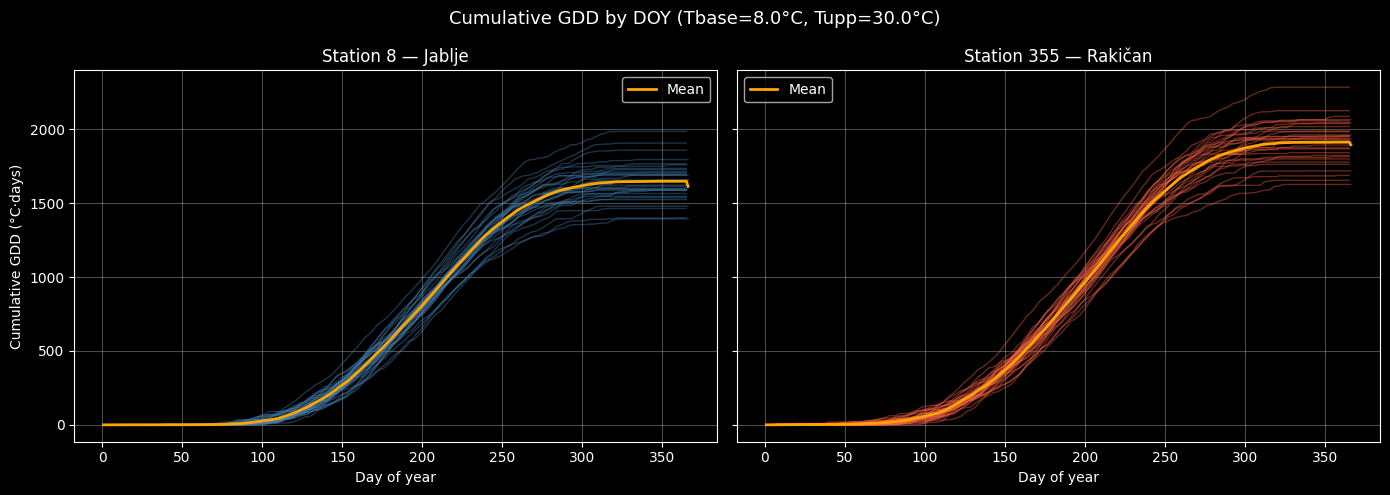

In [9]:
colors = {8: "steelblue", 355: "tomato"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (station_id, label) in zip(axes, STATIONS.items()):
    df = weather[station_id]
    pivot = df.pivot_table(index="doy", columns="year", values="cumgdd")
    for year in pivot.columns:
        ax.plot(pivot.index, pivot[year], alpha=0.4, linewidth=1, color=colors[station_id])
    ax.plot(pivot.index, pivot.mean(axis=1), color="orange", linewidth=2, label="Mean")
    ax.set_title(f"Station {station_id} — {label}")
    ax.set_xlabel("Day of year")
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Cumulative GDD (°C·days)")
fig.suptitle(f"Cumulative GDD by DOY (Tbase={TBASE}°C, Tupp={TUPP}°C)", fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
def compute_milestone_gdd(df, sowing_month, sowing_day, milestones):
    indexed = df.set_index("datum")
    records = []
    for year in df["year"].unique():
        sowing = pd.Timestamp(date(year, sowing_month, sowing_day))
        row = {"year": year}
        for name, n_days in milestones.items():
            end = sowing + pd.Timedelta(days=n_days - 1)
            gdd_slice = indexed.loc[sowing:end, "gdd"]
            row[name] = gdd_slice.sum() if len(gdd_slice) == n_days else float("nan")
        records.append(row)
    return pd.DataFrame(records).set_index("year")

milestone_gdd = {
    station_id: compute_milestone_gdd(weather[station_id], SOWING_MONTH, SOWING_DAY, MILESTONES)
    for station_id in STATIONS
}
milestone_gdd[8]

,emergence,flowering,flowering_end,senescence,max_rooting,maturity,hi_start
year,,,,,,,
1993,30.65,585.10,711.35,1020.85,1031.40,1214.65,531.10
1994,13.95,534.30,683.55,1049.80,1059.65,1310.25,466.30
1995,26.80,443.15,606.05,935.65,946.10,1111.95,390.80
1996,27.05,537.00,652.10,946.80,955.90,1144.25,490.55
1997,26.20,533.65,667.65,982.75,994.00,1251.80,489.40
1998,23.65,576.30,707.10,1092.20,1106.40,1324.70,524.70
1999,27.80,577.15,717.20,1035.00,1047.10,1271.45,510.00
2000,37.00,590.35,686.00,993.95,1007.50,1223.10,522.10
2001,38.25,532.75,680.60,1027.00,1041.20,1264.95,479.25


In [7]:
for station_id, label in STATIONS.items():
    print(f"\n--- {label} (station {station_id}) ---")
    display(milestone_gdd[station_id].describe().loc[["mean", "std", "min", "max"]].round(1))


--- Jablje (station 8) ---


,emergence,flowering,flowering_end,senescence,max_rooting,maturity,hi_start
mean,28.5,580.1,730.2,1072.3,1084.3,1319.5,521.0
std,11.8,61.0,68.5,86.3,87.2,105.6,58.0
min,5.2,443.2,586.1,923.5,935.4,1112.0,390.8
max,54.5,723.3,883.8,1267.2,1282.1,1566.2,652.8



--- Rakičan (station 355) ---


,emergence,flowering,flowering_end,senescence,max_rooting,maturity,hi_start
mean,37.7,660.0,824.1,1193.4,1206.7,1465.7,595.1
std,12.6,58.8,64.6,80.8,81.2,100.0,56.9
min,14.9,531.2,678.8,1037.6,1055.0,1280.2,473.6
max,60.6,784.8,957.8,1374.0,1390.0,1661.3,727.5


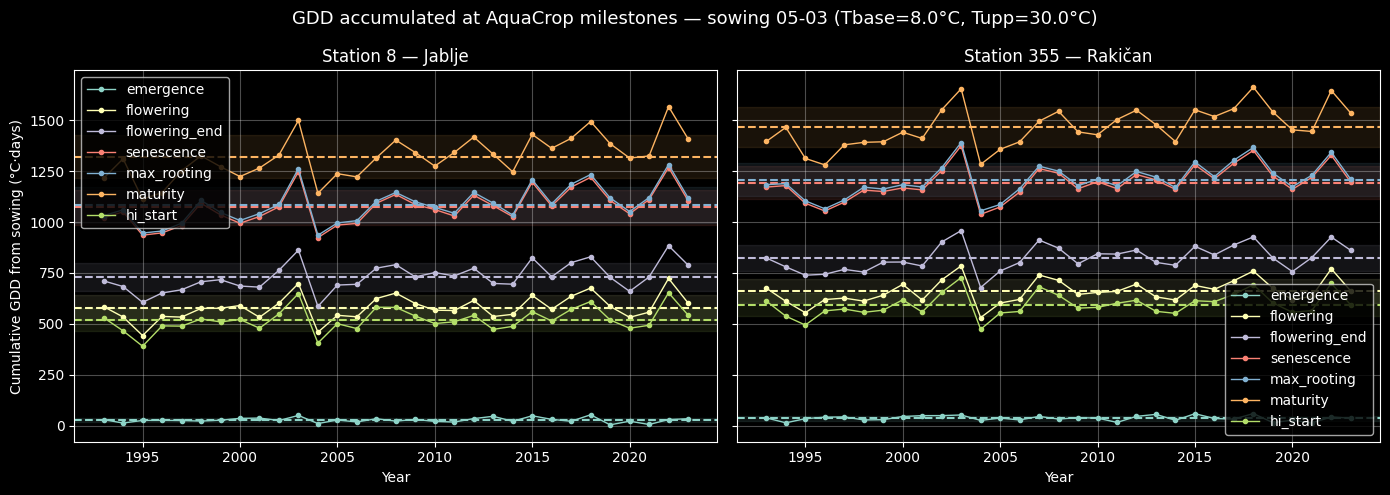

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (station_id, label) in zip(axes, STATIONS.items()):
    for milestone in MILESTONES:
        gdd_series = milestone_gdd[station_id][milestone].dropna()
        mean = gdd_series.mean()
        std = gdd_series.std()
        line, = ax.plot(gdd_series.index, gdd_series.values, marker="o", markersize=3, linewidth=1, label=milestone)
        ax.axhline(mean, color=line.get_color(), linewidth=1.5, linestyle="--")
        ax.axhspan(mean - std, mean + std, color=line.get_color(), alpha=0.10)
    ax.set_title(f"Station {station_id} — {label}")
    ax.set_xlabel("Year")
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Cumulative GDD from sowing (°C·days)")
fig.suptitle(
    f"GDD accumulated at AquaCrop milestones — sowing {SOWING_MONTH:02d}-{SOWING_DAY:02d} "
    f"(Tbase={TBASE}°C, Tupp={TUPP}°C)",
    fontsize=13,
)
plt.tight_layout()
plt.show()